In [1]:
!python -V

Python 3.9.7


In [2]:
import pandas as pd
import pickle

In [3]:
import seaborn as sns
import matplotlib.pyplot as pit
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [4]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experement1")

2025/09/29 18:02:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/09/29 18:02:57 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/home/dzmitry/notebooks/mlruns/1', creation_time=1758971241737, experiment_id='1', last_update_time=1758971241737, lifecycle_stage='active', name='nyc-taxi-experement1', tags={}>

In [5]:
df = pd.read_parquet('./data/green_tripdata_2021-01.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [6]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829628

/tmp/ipykernel_15846/1716593689.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_15846/1716593689.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


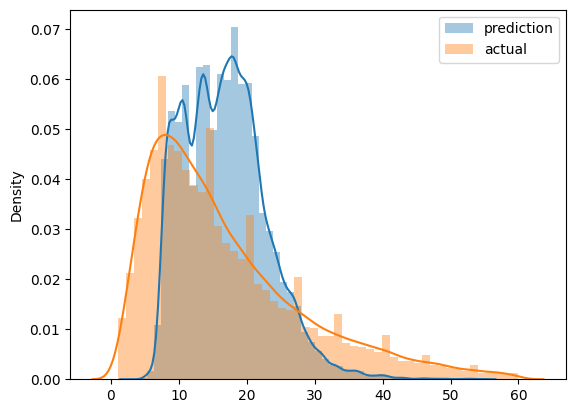

In [7]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

pit.legend()

In [8]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [9]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')

In [10]:
len(df_train), len(df_val)

(73908, 61921)

In [11]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [13]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [15]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715200888857

In [37]:
print(X_val.shape, y_val.shape)

(61921, 13221) (61921,)


In [16]:
with mlflow.start_run():
    mlflow.set_tag("developer", "marta")

    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("val-data-path", "./data/green_tripdata_2021-02.parquet")
    
    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_val)
    
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

In [22]:
mlflow.xgboost.autolog(disable=True)

In [23]:
with mlflow.start_run():

    best_params = {
        'max_depth': 30,
        'learning_rate': 0.96083191268936148, # exp(-3), exp(0) - [0.05, 1]
        'reg_alpha': 0.03290809887656521,
        'reg_lambda': 0.05363980522430369,
        'min_child_weight': 1.5410955874186484,
        'objective': 'reg:linear',
        'seed': 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )
    
    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open("models/prep.b", "wb") as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact("models/prep.b", artifact_path="prep")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")
    

/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:26:43] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation-rmse:6.72416
[1]	validation-rmse:6.66063
[2]	validation-rmse:6.65387
[3]	validation-rmse:6.64287
[4]	validation-rmse:6.62918
[5]	validation-rmse:6.62411
[6]	validation-rmse:6.61897
[7]	validation-rmse:6.61079
[8]	validation-rmse:6.60450
[9]	validation-rmse:6.60062
[10]	validation-rmse:6.59400
[11]	validation-rmse:6.59008
[12]	validation-rmse:6.57969
[13]	validation-rmse:6.57741
[14]	validation-rmse:6.57113
[15]	validation-rmse:6.56553
[16]	validation-rmse:6.55885
[17]	validation-rmse:6.55380
[18]	validation-rmse:6.55205
[19]	validation-rmse:6.54844
[20]	validation-rmse:6.54580
[21]	validation-rmse:6.54194
[22]	validation-rmse:6.53760
[23]	validation-rmse:6.53443
[24]	validation-rmse:6.53261
[25]	validation-rmse:6.52694
[26]	validation-rmse:6.52172
[27]	validation-rmse:6.52061
[28]	validation-rmse:6.51682
[29]	validation-rmse:6.51195
[30]	validation-rmse:6.51274
[31]	validation-rmse:6.50813
[32]	validation-rmse:6.50844
[33]	validation-rmse:6.50833
[34]	validation-rmse:6.5

2025/09/29 18:27:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:27:01] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2025/09/29 18:27:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [ ]:

          
mlflow.set_active_model(model_id="m-bb70a6fd92b24759b5d424390c16378c")

In [44]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [17]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [18]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [24]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [25]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0), # exp(-3), exp(0) - [0.05, 1]
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|                                           | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [19:21:24] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:11.68329                                                           
[1]	validation-rmse:11.19899                                                           
[2]	validation-rmse:10.75627                                                           
[3]	validation-rmse:10.35454                                                           
[4]	validation-rmse:9.98583                                                            
[5]	validation-rmse:9.65277                                                            
[6]	validation-rmse:9.34864                                                            
[7]	validation-rmse:9.07217                                                            
[8]	validation-rmse:8.82316                                                            
[9]	validation-rmse:8.59701                                                            
[10]	validation-rmse:8.39200                                                           
[11]	validation-rmse:8.20910    

/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [19:26:48] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:11.54515                                                           
[1]	validation-rmse:10.94672                                                           
[2]	validation-rmse:10.41325                                                           
[3]	validation-rmse:9.93828                                                            
[4]	validation-rmse:9.51855                                                            
[5]	validation-rmse:9.14591                                                            
[6]	validation-rmse:8.81431                                                            
[7]	validation-rmse:8.52394                                                            
[8]	validation-rmse:8.26882                                                            
[9]	validation-rmse:8.04445                                                            
[10]	validation-rmse:7.84881                                                           
[11]	validation-rmse:7.67699    

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[195]	validation-rmse:6.52827                                                          
[196]	validation-rmse:6.52799                                                          
[197]	validation-rmse:6.52768                                                          
[198]	validation-rmse:6.52720                                                          
[199]	validation-rmse:6.52701                                                          
[200]	validation-rmse:6.52651                                                          
[201]	validation-rmse:6.52618                                                          
[202]	validation-rmse:6.52586                                                          
[203]	validation-rmse:6.52562                                                          
[204]	validation-rmse:6.52528                                                          
[205]	validation-rmse:6.52490                                                          
[206]	validation-rmse:6.52458   

/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [19:48:54] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:8.08230                                                            
[1]	validation-rmse:6.99328                                                            
[2]	validation-rmse:6.71785                                                            
[3]	validation-rmse:6.62030                                                            
[4]	validation-rmse:6.57851                                                            
[5]	validation-rmse:6.55965                                                            
[6]	validation-rmse:6.54744                                                            
[7]	validation-rmse:6.54447                                                            
[8]	validation-rmse:6.53510                                                            
[9]	validation-rmse:6.52943                                                            
[10]	validation-rmse:6.52650                                                           
[11]	validation-rmse:6.52080    

KeyboardInterrupt: 

In [27]:
params = {
    'learning_rate': 0.9225375345845006,
    'max_depth': 6,
    'min_child_weight': 1.7098271527150397,
    'objective': 'reg:linear',
    'reg_alpha': 0.05320718320980476,
    'reg_lambda': 0.00873254896663028,
    'seed': 42
}

In [28]:
mlflow.xgboost.autolog()

booster = xgb.train(
    params=params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, 'validation')],
    early_stopping_rounds=50
)

2025/09/28 20:02:55 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8bf4d8c9d4d44449902ea4eb6539d4d7', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:6.94168
[1]	validation-rmse:6.81906


/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [20:03:03] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[2]	validation-rmse:6.80949
[3]	validation-rmse:6.80044
[4]	validation-rmse:6.78909
[5]	validation-rmse:6.78127
[6]	validation-rmse:6.77842
[7]	validation-rmse:6.77556
[8]	validation-rmse:6.76927
[9]	validation-rmse:6.76783
[10]	validation-rmse:6.76451
[11]	validation-rmse:6.75752
[12]	validation-rmse:6.75368
[13]	validation-rmse:6.74761
[14]	validation-rmse:6.74528
[15]	validation-rmse:6.74617
[16]	validation-rmse:6.74091
[17]	validation-rmse:6.73861
[18]	validation-rmse:6.73977
[19]	validation-rmse:6.73753
[20]	validation-rmse:6.73655
[21]	validation-rmse:6.73426
[22]	validation-rmse:6.73320
[23]	validation-rmse:6.73452
[24]	validation-rmse:6.73057
[25]	validation-rmse:6.72759
[26]	validation-rmse:6.72526
[27]	validation-rmse:6.72321
[28]	validation-rmse:6.71799
[29]	validation-rmse:6.71542
[30]	validation-rmse:6.71340
[31]	validation-rmse:6.70979
[32]	validation-rmse:6.70671
[33]	validation-rmse:6.70591
[34]	validation-rmse:6.70449
[35]	validation-rmse:6.70158
[36]	validation-rmse:6

2025/09/28 20:03:28 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2025/09/28 20:03:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/28 20:03:28 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/dzmitry/anaconda3/envs/mlops-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [20:03:28] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2025/09/28 20:03:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
